In [1]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    
if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/NUIN")

    REPO = Path("/content/motionnet_repo")
    if REPO.exists():
        !cd {REPO} && git pull
    else:
        !git clone https://github.com/guardomayas/motionnet.git {REPO}
    
    !cd {REPO} && pip install -q -e .
    %cd /content
    
    DATA_PATH = Path("/content/vanhateren")
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True)
        !cp "{DRIVE}/van_hateren/"*.iml {DATA_PATH}/

    CKPT_DIR = DRIVE / "motionnet_runs"
else:
    DATA_PATH = Path("~/NUIN/van_hateren/vanhateren_iml").expanduser()
    CKPT_DIR = Path("runs")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH, len(list(DATA_PATH.glob("*.iml"))), "images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for motionnet (pyproject.toml) ... done
/content
/content/vanhateren 400 images


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from motionnet.dataset import GetNaturalMovies, animate_sample, DiskCachedDataset
from torch.utils.data import DataLoader
from tqdm import tqdm
from IPython.display import HTML, display
from motionnet.dataset.van_hateren_utils import log_image
from pathlib import Path
import seaborn as sns
import motionnet
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os
sns.set_context("talk")
print(motionnet.__file__)   # should end in src/motionnet/__init__.py
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

/content/motionnet_repo/src/motionnet/__init__.py
Using device: cuda
/content


In [ ]:
## GLOBAL VARS
CACHE_DIR = (DRIVE / "motionnet/cache") if IN_COLAB else Path("/home/guardomayas/NUIN/motionnet/data/coeffs")
N_IMAGES = 300
RNG      = np.random.default_rng(0)
# DPP      = 1/60 # Van Hateren images are 1/60 deg per pixel 
plot_vid = True


In [4]:
from motionnet.dataset import build_coeff_cache, split_images

CFG = dict(eye_size=50, spacing_px = 7, blur_px=13, start_jitter=100,
           frames_per_segment=75*1.5, fps=75,
           vel_std_deg_s=(120, 70), samples_per_image=5)

RHO_PHI = 1.08                                   # matches the class default
SIGMA_PX = CFG["blur_px"] * RHO_PHI / 2.3548

train_files, val_files = split_images(DATA_PATH, n_images=N_IMAGES,
                                      val_frac=0.2, stride=1)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
train_cache = CACHE_DIR / f"train_n{len(train_files)}_blur{CFG['blur_px']}.npy"
val_cache   = CACHE_DIR / f"val_n{len(val_files)}_blur{CFG['blur_px']}.npy"

if not train_cache.exists():
    build_coeff_cache(train_files, train_cache, SIGMA_PX)
if not val_cache.exists():
    build_coeff_cache(val_files, val_cache, SIGMA_PX)

train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,
                            seed=1, **CFG), cache_dir=CACHE_DIR/"movies_train")
val_ds   = DiskCachedDataset(GetNaturalMovies(files=val_files, coeff_cache=val_cache,
                            seed=99, **CFG), cache_dir=CACHE_DIR/"movies_val")

print("Training data: ", len(train_ds))
print("Validation data: ", len(val_ds))

Training data:  1200
Validation data:  300


/tmp/ipykernel_11839/3706207440.py:22: RuntimeWarning: excursion budget is tight on x: limit 479 px is 1.9 sigma of the position spread (246 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,
/tmp/ipykernel_11839/3706207440.py:22: RuntimeWarning: excursion budget is tight on y: limit 223 px is 1.6 sigma of the position spread (143 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,
/tmp/ipykernel_11839/3706207440.py:24: RuntimeWarning: excursion budget is tight on x: limit 479 px is 1.9 sigma of the position spread (246 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_s

In [5]:
from IPython.display import HTML, display
anim = animate_sample(train_ds, idx=0, stride=3)
display(HTML(anim.to_jshtml()))
#     # plt.close(anim._fig)          # suppress the static figure

AttributeError: 'DiskCachedDataset' object has no attribute 'source_image'

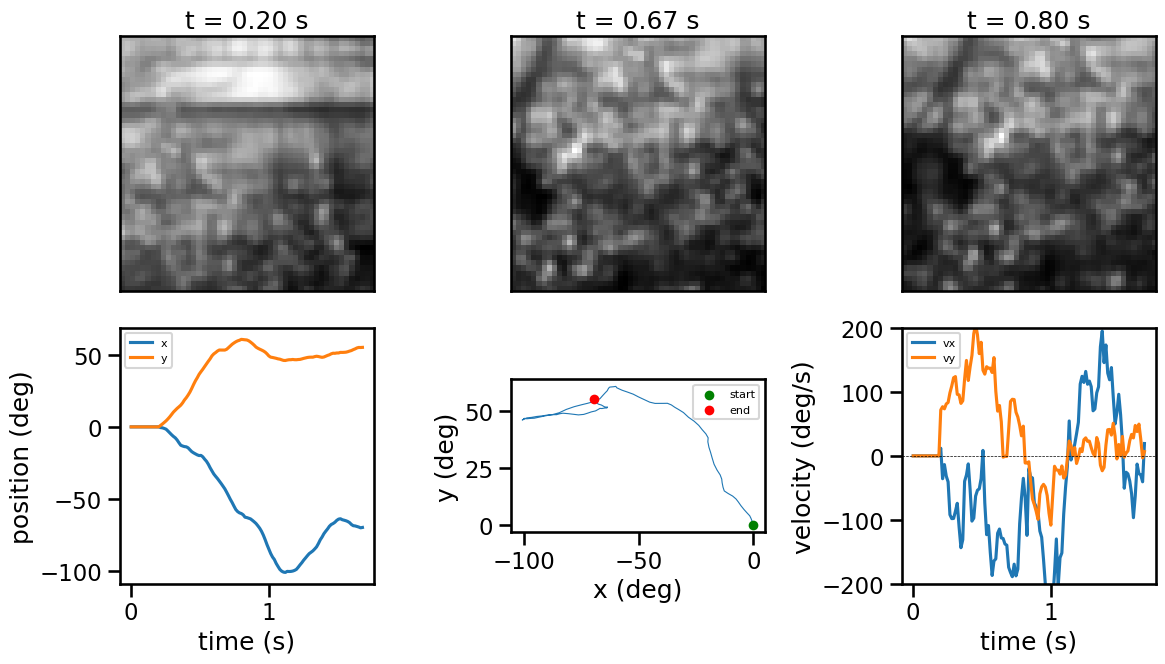

In [6]:
d = train_ds
s = d[0]
movie = s["movie"].numpy()
vel   = s["vel_deg_s"].numpy()
pos   = s["pos_px"].numpy() * d.dpp        # source px -> deg
t_s   = np.arange(len(vel)) / d.fps
frames = [15, 50, 60]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i, f in enumerate(frames):
    axes[0, i].imshow(movie[f, 0], cmap="gray", interpolation="nearest")
    axes[0, i].set_title(f"t = {f / d.fps:.2f} s")
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

axes[1, 0].plot(t_s, pos[:, 0], label="x")
axes[1, 0].plot(t_s, pos[:, 1], label="y")
axes[1, 0].set(xlabel="time (s)", ylabel="position (deg)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(pos[:, 0], pos[:, 1], lw=0.8)
axes[1, 1].scatter(*pos[0], c="g", s=30, zorder=3, label="start")
axes[1, 1].scatter(*pos[-1], c="r", s=30, zorder=3, label="end")
axes[1, 1].set(xlabel="x (deg)", ylabel="y (deg)")
axes[1, 1].set_aspect("equal")
axes[1, 1].legend(fontsize=8)

axes[1, 2].plot(t_s, vel[:, 0], label="vx")
axes[1, 2].plot(t_s, vel[:, 1], label="vy")
axes[1, 2].axhline(0, ls='--', color="k", lw=0.5)
axes[1, 2].set(xlabel="time (s)", ylabel="velocity (deg/s)", ylim=(-200,200))
axes[1, 2].legend(fontsize=8)

fig.tight_layout()

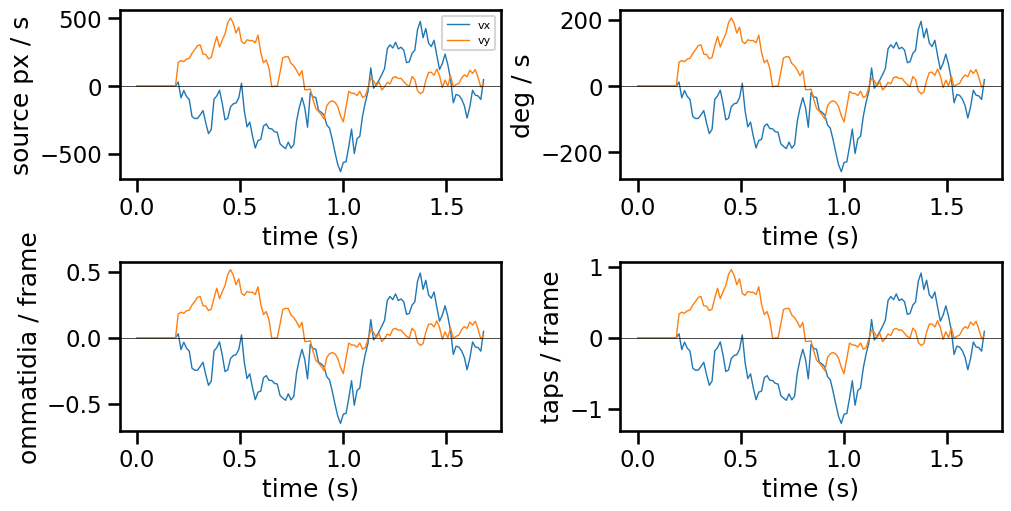

In [7]:
#deg_s = tap_frame × spacing_px × fps × dpp.
vels = [
    (s["vel_px_s"].numpy(),      "source px / s"),
    (s["vel_deg_s"].numpy(),     "deg / s"),
    (s["vel_omm_frame"].numpy(), "ommatidia / frame"),
    (s["vel_tap_frame"].numpy(), "taps / frame"),
]
t_s = np.arange(len(vels[0][0])) / d.fps

fig, axes = plt.subplots(2, 2, figsize=(10, 5), layout="constrained")
for ax, (v, unit) in zip(axes.ravel(), vels):
    ax.plot(t_s, v[:, 0], label="vx", lw=1)
    ax.plot(t_s, v[:, 1], label="vy", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set(xlabel="time (s)", ylabel=unit)
axes[0,0].legend(fontsize=8)

## Setting up a CNN

In [8]:
print(movie.shape)

(127, 1, 50, 50)


In [9]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4,
                      pin_memory=True, drop_last=True, persistent_workers=True)
val_dl   = DataLoader(val_ds, batch_size=16, num_workers=2,
                      persistent_workers=True)

In [10]:
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch

class CNN(nn.Module):
    def __init__(self,
                 num_neurons=8,
                 height=50,
                 width=50,
                 rf_size_1=5,
                 rf_size_2=7,
                 max_delay=70,
                 num_subunits_1=8,
                 num_subunits_2=8,
                 initial_bias=1.0,
                 mean_function=F.softplus,
                 input_noise_std=0.0,
                 activity_noise_std=0.0,
                 dropout_p=0.0):

        super().__init__()

        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # Noise / regularization
        self.input_noise_std = input_noise_std
        self.activity_noise_std = activity_noise_std
        self.dropout = nn.Dropout(p=dropout_p)

        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,
            bias=True,
        )

        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        self.layer3 = nn.Linear(num_subunits_2, num_neurons)

        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def add_input_noise(self, movie):
        if self.training and self.input_noise_std > 0:
            movie = movie + self.input_noise_std * torch.randn_like(movie)

            # Optional if your movie is normalized to [0, 1]
            # movie = movie.clamp(0.0, 1.0)

        return movie

    def add_activity_noise(self, x):
        if self.training and self.activity_noise_std > 0:
            # Multiplicative noise. Keeps noise scale proportional to activity.
            noise = self.activity_noise_std * torch.randn_like(x)
            x = x * (1.0 + noise)

            # Since activations after ReLU should remain nonnegative
            x = torch.clamp(x, min=0.0)

        return x

    def forward(self, movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """

        movie = self.add_input_noise(movie)

        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_conv(x)

        _, N1, H1, W1 = x.shape

        x = x.reshape(B, T, N1, H1, W1)

        # -------------------------------------------------------
        # 2. Temporal conv at each spatial location
        # -------------------------------------------------------
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # causal temporal padding
        x = F.pad(x, (self.max_delay - 1, 0))
        x = self.temporal_conv(x)

        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        x = self.add_activity_noise(x)

        # -------------------------------------------------------
        # 3. Second spatial conv
        # -------------------------------------------------------
        x = x.reshape(B * T, N1, H1, W1)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.add_activity_noise(x)

        _, N2, H2, W2 = x.shape

        # -------------------------------------------------------
        # 4. Pooling over space + linear readout
        # -------------------------------------------------------
        x_pool = x.mean(dim=(-1, -2))              # (B*T, N2)

        # Optional dropout after pooling
        x_pool = self.dropout(x_pool)

        drive = self.layer3(x_pool)
        rates = self.mean_function(drive)

        rates = rates.reshape(B, T, self.num_neurons)

        return rates + 1e-8
    
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.1)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N), nonnegative
        pred_vel = self.decoder(rates)      # (B, T, 2), signed

        if return_rates:
            return rates, pred_vel

        return pred_vel

In [11]:
output_neurons = 8

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=5,
    num_subunits_2=6,
    initial_bias=1,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.0,
    activity_noise_std=0.0,
    dropout_p=0.0,
)
model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

In [12]:
### Over fit a small dataset
loss_fn = nn.MSELoss()
batch = next(iter(train_dl))

movie = batch["movie"].to(device)
target = batch["vel_tap_frame"].to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(1000):
    pred = model(movie)
    valid = slice(train_ds.gray_frames, None)
    loss = loss_fn(pred[:, valid], target[:, valid])
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 100 == 0:
        print(step, loss.item())

0 0.2517308294773102
100 0.2005189210176468
200 0.15357910096645355
300 0.08912410587072372
400 0.0666096955537796
500 0.05462345853447914
600 0.04507856070995331
700 0.03786414861679077
800 0.033612750470638275
900 0.03073795884847641


/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py:54: RuntimeWarning: acceptance rate 78% over 50 samples (64 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  data = [self.dataset[idx] for idx in possibly_batched_index]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py:54: RuntimeWarning: acceptance rate 76% over 50 samples (66 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  data = [self.dataset[idx] for idx in possibly_batched_index]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py:54: RuntimeWarning: acceptance rate 80% over 111 samples (139 draws

In [13]:
t = target[:, valid]
print("target var:", t.var().item())                    # predict-mean baseline
print("R²:", 1 - loss.item() / t.var().item())
print("pred std:", pred[:, valid].std().item(), "target std:", t.std().item())
err = (pred[:, valid] - target[:, valid]).pow(2).mean((0, 1))
print(1 - err / target[:, valid].var((0, 1)))

target var: 0.20449016988277435
R²: 0.8603731787191279
pred std: 0.416734516620636 target std: 0.4522058963775635
tensor([0.8794, 0.7919], device='cuda:0', grad_fn=<RsubBackward1>)


In [14]:
print("train batches per epoch:", len(train_dl))
print("val batches per epoch:", len(val_dl))
print("train samples:", len(train_dl.dataset))
print("val samples:", len(val_dl.dataset))

train batches per epoch: 75
val batches per epoch: 19
train samples: 1200
val samples: 300


## full training loop


In [15]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
### BEST PERFORMING MODEL SO FAR (6 neurons, RFs: 9 and 11, 
#                               subunits 5 and 6, 15 delay)
# dropout 0.02, input noise 0.005, activity noise 0.02, initial bias 1.0
output_neurons = 8

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=5,
    num_subunits_2=6,
    initial_bias=1.0,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.00,
    activity_noise_std=0.00,
    dropout_p=0.00,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["vel_tap_frame"].to(device)

        pred = model(movie)

        valid = slice(train_ds.gray_frames, None)
        loss = loss_fn(pred[:, valid], target[:, valid])

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        # pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 150

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_dl,
        optimizer=optimizer,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_dl,
            optimizer=None,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/75 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/19 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py:54: RuntimeWarning: acceptance rate 75% over 50 samples (67 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  data = [self.dataset[idx] for idx in possibly_batched_index]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py:54: RuntimeWarning: acceptance rate 76% over 50 samples (66 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  data = [self.dataset[idx] for idx in possibly_batched_index]


Epoch 001 | train 0.1931 | val 0.1868


Tiny instant epoch 002 train:   0%|          | 0/75 [00:00<?, ?it/s]

...

Tiny instant epoch 010 train:   0%|          | 0/75 [00:00<?, ?it/s]

Tiny instant epoch 010 val:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 010 | train 0.0772 | val 0.0801


Tiny instant epoch 011 train:   0%|          | 0/75 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Motion CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()